In [2]:
#IMPORT NECESSARY LIBRARIES
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
#IMPORT DATA
from google.colab import files
uploaded=files.upload()

Saving loan_approval_1000.csv to loan_approval_1000.csv


In [4]:
#READ DATA
df=pd.read_csv('loan_approval_1000.csv')
df_copy=df.copy()
df_copy

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,Salaried,0
1,49,141178.0,328226,487,Salaried,0
2,35,56368.0,312805,356,Self-Employed,0
3,28,26783.0,218484,319,Salaried,0
4,41,131530.0,315064,572,Self-Employed,0
...,...,...,...,...,...,...
995,58,112447.0,259717,572,Unemployed,0
996,22,134994.0,314167,544,Unemployed,0
997,27,109899.0,169654,749,Salaried,1
998,38,40049.0,240868,546,Unemployed,0


In [5]:
#DATA UNDERSTANDING
df_copy.shape

(1000, 6)

In [6]:
df_copy.isna().sum()

,0
Age,0
Income,50
Loan_Amount,0
Credit_Score,0
Employment_Type,50
Loan_Approved,0


In [7]:
df_copy.describe()

,Age,Income,Loan_Amount,Credit_Score,Loan_Approved
count,1000.000000,950.000000,1000.000000,1000.000000,1000.000000
mean,40.445000,84881.753684,270051.753000,610.381000,0.315000
std,11.499183,37717.819324,128863.845332,174.696974,0.464748
min,21.000000,20060.000000,51969.000000,300.000000,0.000000
25%,30.000000,51909.000000,160877.250000,460.000000,0.000000
50%,41.000000,83551.500000,266606.500000,612.000000,0.000000
75%,50.000000,116955.750000,383224.500000,764.000000,1.000000
max,59.000000,149972.000000,499370.000000,898.000000,1.000000


In [8]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              1000 non-null   int64  
 1   Income           950 non-null    float64
 2   Loan_Amount      1000 non-null   int64  
 3   Credit_Score     1000 non-null   int64  
 4   Employment_Type  950 non-null    object 
 5   Loan_Approved    1000 non-null   int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 47.0+ KB


In [9]:
len(df_copy)

1000

In [10]:
#NULL IMPUTATION
df_copy['Income'].fillna(df_copy['Income'].median(),inplace=True)
df_copy['Employment_Type'].fillna(df_copy['Employment_Type'].mode()[0],inplace=True)
df_copy.isna().sum()

/tmp/ipykernel_694/403389613.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Income'].fillna(df_copy['Income'].median(),inplace=True)
/tmp/ipykernel_694/403389613.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

,0
Age,0
Income,0
Loan_Amount,0
Credit_Score,0
Employment_Type,0
Loan_Approved,0


In [11]:
#ENCODING CATEGORICAL DATA
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_copy['Employment_Type']=le.fit_transform(df_copy['Employment_Type'])
df_copy

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,0,0
1,49,141178.0,328226,487,0,0
2,35,56368.0,312805,356,1,0
3,28,26783.0,218484,319,0,0
4,41,131530.0,315064,572,1,0
...,...,...,...,...,...,...
995,58,112447.0,259717,572,2,0
996,22,134994.0,314167,544,2,0
997,27,109899.0,169654,749,0,1
998,38,40049.0,240868,546,2,0


In [12]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
x=df_copy.drop(['Loan_Approved'],axis=1)
y=df_copy['Loan_Approved']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [13]:
#MODEL TRAINING
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)


LogisticRegression(max_iter=1000)

In [14]:
#MODEL EVLUATION(manual testing)
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1])

In [15]:
df_copy

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,0,0
1,49,141178.0,328226,487,0,0
2,35,56368.0,312805,356,1,0
3,28,26783.0,218484,319,0,0
4,41,131530.0,315064,572,1,0
...,...,...,...,...,...,...
995,58,112447.0,259717,572,2,0
996,22,134994.0,314167,544,2,0
997,27,109899.0,169654,749,0,1
998,38,40049.0,240868,546,2,0


In [16]:
#MOEDL EVALUATION
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       135
           1       0.70      0.62      0.66        65

    accuracy                           0.79       200
   macro avg       0.76      0.74      0.75       200
weighted avg       0.79      0.79      0.79       200



In [21]:
from sklearn.metrics import accuracy_score,confusion_matrix
print("ACCUARACY:",accuracy_score(y_test,y_pred))


ACCUARACY: 0.79


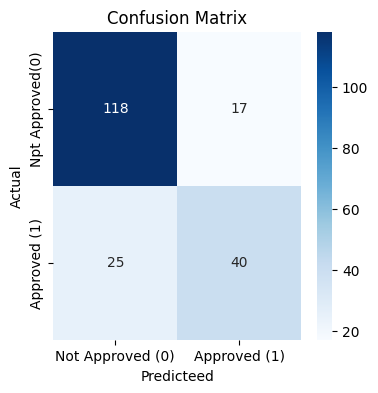

In [24]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm,
              annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not Approved (0)','Approved (1)'],
            yticklabels=['Npt Approved(0)','Approved (1)'])
plt.xlabel('Predicteed')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
#MODEL DEPLOYEMENT
from pickle import dump
dump(model,open('model.pkl','wb'))
